# Inventory impact under persistent adverse selection

This notebook asks one economic question:

> If a trader has a persistent edge after pricing and every ordinary fee, how much expected value can they extract before inventory impact makes the next liability-increasing trade uneconomic?

## Part 1 — define the test

The attacker repeatedly mints the same mispriced 1× range and holds every position through settlement. Its residual edge is an assumption, not an estimate of oracle error or the base fee:

- $\epsilon$: persistent expected edge per dollar of quantity, already net of every ordinary fee.
- $q$: quantity of the next fill; at 1× this is also its maximum net payout.
- $L$: current payout liability.
- $B$: inventory-impact scale, set here to the current $50,000 one-minute testnet allocation.
- $r$: maximum marginal inventory-impact rate.
- $I=\Phi(L_{after})-\Phi(L_{before})$: inventory charge retained when the attacker holds through settlement.

The next trade's expected profit is $\Pi=\epsilon q-I$. The attacker submits it only while $\Pi>0$.

This is deliberately narrow. Known pricing errors still need to be fixed or gated. Inventory impact only responds to liability movement, and this test does not establish protection against every arbitrage strategy.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SIM_DIR = Path.cwd() if (Path.cwd() / "python_indexes").is_dir() else Path.cwd() / "packages/predict/simulations"
if str(SIM_DIR) not in sys.path:
    sys.path.insert(0, str(SIM_DIR))
from python_indexes.strike_payout_tree import StrikePayoutTree

FLOAT = 1_000_000_000
DUSDC = 1_000_000
LAMBDA = 250_000_000

# Core inputs. Edge is already net of pricing and every ordinary fee.
IMPACT_SCALE_DOLLARS = 50_000
B = IMPACT_SCALE_DOLLARS * DUSDC
EDGE_RATES = (10_000_000, 20_000_000)  # 1c and 2c per $1 of quantity
CANDIDATE_RATES = (0, 10_000_000, 20_000_000, 25_000_000, 30_000_000, 40_000_000)
START_UTILIZATIONS = (0.0, 0.5, 0.8)
FILL_QUANTITY_DOLLARS = 1_000
FILL_QUANTITY = FILL_QUANTITY_DOLLARS * DUSDC
MAX_LIABILITY_MULTIPLE = 2.0

# Team decision inputs. Leave unset to report the frontier without selecting r.
MAX_ACCEPTABLE_LP_LOSS_DOLLARS = None
MAX_REFERENCE_CHARGE_DOLLARS = None
REFERENCE_UTILIZATION = 0.50
REFERENCE_DELTA_L_PER_QUANTITY = 0.625
REFERENCE_QUANTITY_DOLLARS = 1_000


def mul_down(x: int, y: int) -> int:
    return x * y // FLOAT


def payout_liability(max_net_payout: int, total_net_payout: int, lam: int = LAMBDA) -> int:
    return max_net_payout + mul_down(lam, total_net_payout - max_net_payout)


def phi(liability: int, scale: int, max_rate: int) -> int:
    """Exact integer-operation order of Move inventory_impact_potential_for_liability."""
    if max_rate == 0 or liability == 0:
        return 0
    capped = min(liability, scale)
    utilization = capped * FLOAT // scale
    marginal_rate = mul_down(max_rate, utilization)
    potential_at_cap = mul_down(marginal_rate, capped) // 2
    if liability <= scale:
        return potential_at_cap
    return potential_at_cap + mul_down(max_rate, liability - scale)


def inventory_impact(before: int, after: int, scale: int, max_rate: int) -> int:
    return phi(after, scale, max_rate) - phi(before, scale, max_rate)


def new_tree() -> StrikePayoutTree:
    return StrikePayoutTree(
        min_strike=10,
        tick_size=10,
        max_strike=100,
        neg_inf=0,
        pos_inf=2**64 - 1,
    )


def tree_liability(tree: StrikePayoutTree, lam: int = LAMBDA) -> int:
    maximum, total = tree.net_payout_reserve_terms()
    return payout_liability(maximum, total, lam)


def dollars(atoms: int | float) -> float:
    return atoms / DUSDC


# Exact parity gates from Move inventory-impact tests.
assert inventory_impact(0, 3_000_000_000, 4_000_000_000, 200_000_000) == 225_000_000
assert inventory_impact(3_000_000_000, 5_000_000_000, 4_000_000_000, 200_000_000) == 375_000_000
assert inventory_impact(0, 1_000_000_000, 10_000_000_000, 200_000_000) == 10_000_000

rounding_tree = new_tree()
rounding_tree.insert_range(0, 50, 100_000_000, 0)
rounding_tree.insert_range(50, 2**64 - 1, 10_000_000, 0)
rounding_before = tree_liability(rounding_tree, 333_333_333)
assert phi(rounding_before, 50_000_000, FLOAT) == 78_333_333
rounding_tree.insert_range(50, 2**64 - 1, 30_000_000, 0)
rounding_after = tree_liability(rounding_tree, 333_333_333)
assert phi(rounding_after, 50_000_000, FLOAT) == 88_333_333
assert inventory_impact(rounding_before, rounding_after, 50_000_000, FLOAT) == 10_000_000

pile_on_tree = new_tree()
pile_on_tree.insert_range(20, 40, FILL_QUANTITY, 0)
assert pile_on_tree.net_payout_reserve_terms() == (FILL_QUANTITY, FILL_QUANTITY)

config_summary = pd.Series(
    {
        "impact scale B": f"${IMPACT_SCALE_DOLLARS:,.0f}",
        "persistent edges": ", ".join(f"{rate / FLOAT:.0%}" for rate in EDGE_RATES),
        "candidate maximum rates": ", ".join(f"{rate / FLOAT:.1%}" for rate in CANDIDATE_RATES),
        "finite fill quantity": f"${FILL_QUANTITY_DOLLARS:,.0f}",
        "starting utilization": ", ".join(f"{value:.0%}" for value in START_UTILIZATIONS),
        "LP loss budget": "TEAM INPUT REQUIRED" if MAX_ACCEPTABLE_LP_LOSS_DOLLARS is None else f"${MAX_ACCEPTABLE_LP_LOSS_DOLLARS:,.2f}",
        "reference charge limit": "TEAM INPUT REQUIRED" if MAX_REFERENCE_CHARGE_DOLLARS is None else f"${MAX_REFERENCE_CHARGE_DOLLARS:,.2f}",
    },
    name="value",
)
display(config_summary.to_frame())
print("Move parity passed: worked, flow, rounding-carry, and payout-tree pile-on checks are exact.")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

,value
impact scale B,"$50,000"
persistent edges,"1%, 2%"
candidate maximum rates,"0.0%, 1.0%, 2.0%, 2.5%, 3.0%, 4.0%"
finite fill quantity,"$1,000"
starting utilization,"0%, 50%, 80%"
LP loss budget,TEAM INPUT REQUIRED
reference charge limit,TEAM INPUT REQUIRED


Move parity passed: worked, flow, rounding-carry, and payout-tree pile-on checks are exact.


,edge,r,status,strictly deters?,stopping utilization,cumulative extraction ($)
0,1%,0.0%,not bounded: edge exceeds capped rate,False,unbounded,unbounded
1,1%,1.0%,zero margin at the cap; never strictly overcha...,False,100%,$250.00
2,1%,2.0%,strictly deterred below the cap,True,50%,$125.00
3,1%,2.5%,strictly deterred below the cap,True,40%,$100.00
4,1%,3.0%,strictly deterred below the cap,True,33%,$83.33
5,1%,4.0%,strictly deterred below the cap,True,25%,$62.50
6,2%,0.0%,not bounded: edge exceeds capped rate,False,unbounded,unbounded
7,2%,1.0%,not bounded: edge exceeds capped rate,False,unbounded,unbounded
8,2%,2.0%,zero margin at the cap; never strictly overcha...,False,100%,$500.00
9,2%,2.5%,strictly deterred below the cap,True,80%,$400.00


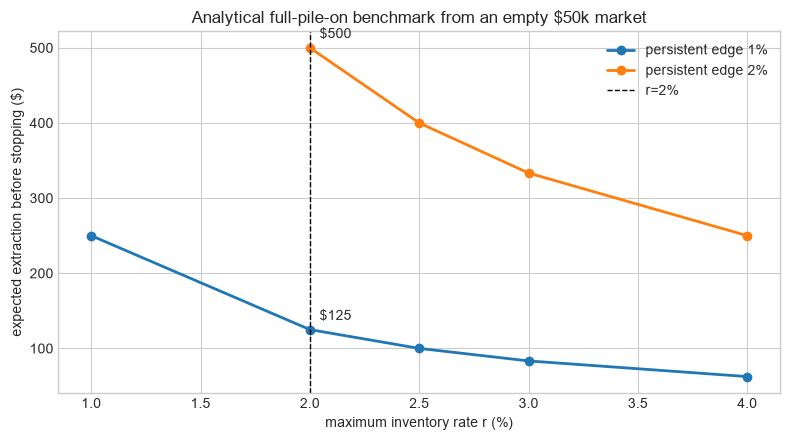

At r=2%: a 1c edge reaches marginal break-even near 50% utilization after about $125 of expected extraction.
At r=2%: a 2c edge remains profitable up to the cap, extracts about $500, then reaches zero margin rather than a strictly negative return.


In [2]:
analytic_rows = []
for edge_rate in EDGE_RATES:
    edge = edge_rate / FLOAT
    for max_rate_atoms in CANDIDATE_RATES:
        rate = max_rate_atoms / FLOAT
        if rate < edge:
            status = "not bounded: edge exceeds capped rate"
            stopping_utilization = np.inf
            cumulative_extraction = np.inf
            strictly_deters = False
        elif rate == edge:
            status = "zero margin at the cap; never strictly overcharged"
            stopping_utilization = 1.0
            cumulative_extraction = IMPACT_SCALE_DOLLARS * edge**2 / (2 * rate)
            strictly_deters = False
        else:
            status = "strictly deterred below the cap"
            stopping_utilization = edge / rate
            cumulative_extraction = IMPACT_SCALE_DOLLARS * edge**2 / (2 * rate)
            strictly_deters = True
        analytic_rows.append(
            {
                "edge": edge,
                "r": rate,
                "status": status,
                "strictly deters?": strictly_deters,
                "stopping utilization": stopping_utilization,
                "cumulative extraction ($)": cumulative_extraction,
            }
        )

analytic = pd.DataFrame(analytic_rows)
analytic_display = analytic.copy()
analytic_display["edge"] = analytic_display["edge"].map(lambda value: f"{value:.0%}")
analytic_display["r"] = analytic_display["r"].map(lambda value: f"{value:.1%}")
analytic_display["stopping utilization"] = analytic_display["stopping utilization"].map(
    lambda value: "unbounded" if np.isinf(value) else f"{value:.0%}"
)
analytic_display["cumulative extraction ($)"] = analytic_display["cumulative extraction ($)"].map(
    lambda value: "unbounded" if np.isinf(value) else f"${value:,.2f}"
)
display(analytic_display)

fig, ax = plt.subplots(figsize=(8, 4.5))
for edge_rate in EDGE_RATES:
    edge = edge_rate / FLOAT
    subset = analytic[analytic["edge"] == edge]
    bounded = subset[np.isfinite(subset["cumulative extraction ($)"])]
    ax.plot(
        bounded["r"] * 100,
        bounded["cumulative extraction ($)"],
        marker="o",
        linewidth=2,
        label=f"persistent edge {edge:.0%}",
    )
    focus = bounded[np.isclose(bounded["r"], 0.02)]
    if not focus.empty:
        row = focus.iloc[0]
        ax.annotate(
            f"${row['cumulative extraction ($)']:,.0f}",
            (row["r"] * 100, row["cumulative extraction ($)"]),
            xytext=(7, 7),
            textcoords="offset points",
        )
ax.axvline(2.0, color="black", linestyle="--", linewidth=1, label="r=2%")
ax.set(
    xlabel="maximum inventory rate r (%)",
    ylabel="expected extraction before stopping ($)",
    title="Analytical full-pile-on benchmark from an empty $50k market",
)
ax.legend()
fig.tight_layout()
plt.show()

print("At r=2%: a 1c edge reaches marginal break-even near 50% utilization after about $125 of expected extraction.")
print("At r=2%: a 2c edge remains profitable up to the cap, extracts about $500, then reaches zero margin rather than a strictly negative return.")

## Part 2 — replay the exact finite-fill attack

The analytical benchmark treats flow as infinitesimal. Real fills cross a range of marginal rates and use rounded integer arithmetic, so this section replays fixed $1,000 fills against the exact potential:

1. Observe the current same-range book.
2. Quote one more fill and calculate its exact liability increase and inventory charge.
3. Calculate expected incremental profit, $\epsilon q-I$.
4. Accept the fill only when that profit is strictly positive.
5. Repeat until the next fill is uneconomic or an explicitly labeled safety horizon is reached.

The attacker holds accepted positions through settlement, so collected inventory impact remains with the expiry rather than being paid back as a voluntary-close rebate.

In [3]:
ATTACK_LOWER = 20
ATTACK_UPPER = 40


def run_attack(edge_rate: int, max_rate: int, start_utilization: float, fill_quantity: int = FILL_QUANTITY):
    tree = new_tree()
    starting_liability = int(round(start_utilization * B))
    if starting_liability:
        tree.insert_range(ATTACK_LOWER, ATTACK_UPPER, starting_liability, 0)
    assert tree_liability(tree) == starting_liability

    cumulative_quantity = 0
    cumulative_edge = 0
    cumulative_charge = 0
    trace_rows = []
    safety_liability = int(MAX_LIABILITY_MULTIPLE * B)
    max_steps = int(np.ceil((safety_liability - starting_liability) / fill_quantity)) + 2
    stop_reason = "safety horizon reached"

    for step in range(1, max_steps + 1):
        before = tree_liability(tree)
        tree.insert_range(ATTACK_LOWER, ATTACK_UPPER, fill_quantity, 0)
        after = tree_liability(tree)
        assert after - before == fill_quantity
        charge = inventory_impact(before, after, B, max_rate)
        gross_edge = mul_down(edge_rate, fill_quantity)
        incremental_profit = gross_edge - charge
        accepted = incremental_profit > 0

        if accepted:
            cumulative_quantity += fill_quantity
            cumulative_edge += gross_edge
            cumulative_charge += charge
        else:
            tree.remove_range(ATTACK_LOWER, ATTACK_UPPER, fill_quantity, 0)

        trace_rows.append(
            {
                "step": step,
                "accepted": accepted,
                "L before ($)": dollars(before),
                "L after quote ($)": dollars(after),
                "utilization after quote": after / B,
                "gross edge ($)": dollars(gross_edge),
                "inventory charge ($)": dollars(charge),
                "incremental profit ($)": dollars(incremental_profit),
                "cumulative extraction ($)": dollars(cumulative_edge - cumulative_charge),
            }
        )

        if not accepted:
            if max_rate == edge_rate:
                stop_reason = "next fill reaches zero margin at the capped rate"
            else:
                stop_reason = "next fill is strictly unprofitable"
            break

        if after >= safety_liability:
            if max_rate < edge_rate:
                stop_reason = "inventory rate cannot stop this edge; safety horizon reached"
            else:
                stop_reason = "safety horizon reached before an economic stop"
            break

    final_liability = tree_liability(tree)
    if max_rate < edge_rate:
        structural_status = "not bounded: edge exceeds capped rate"
    elif max_rate == edge_rate:
        structural_status = "zero margin only at/above the cap"
    else:
        structural_status = "strict deterrence is possible"

    summary = {
        "edge": edge_rate / FLOAT,
        "r": max_rate / FLOAT,
        "starting utilization": start_utilization,
        "structural status": structural_status,
        "stop reason": stop_reason,
        "final utilization": final_liability / B,
        "accepted quantity ($)": dollars(cumulative_quantity),
        "gross residual edge ($)": dollars(cumulative_edge),
        "retained inventory impact ($)": dollars(cumulative_charge),
        "cumulative attacker profit ($)": dollars(cumulative_edge - cumulative_charge),
    }
    return summary, pd.DataFrame(trace_rows)


# One auditable prospective trade: 1c edge, r=2%, $1k fill, starting at 40% utilization.
worked_tree = new_tree()
worked_before = int(0.40 * B)
worked_tree.insert_range(ATTACK_LOWER, ATTACK_UPPER, worked_before, 0)
worked_tree.insert_range(ATTACK_LOWER, ATTACK_UPPER, FILL_QUANTITY, 0)
worked_after = tree_liability(worked_tree)
worked_edge = mul_down(10_000_000, FILL_QUANTITY)
worked_charge = inventory_impact(worked_before, worked_after, B, 20_000_000)
worked = pd.Series(
    {
        "L before": f"${dollars(worked_before):,.2f}",
        "L after": f"${dollars(worked_after):,.2f}",
        "fill quantity": f"${dollars(FILL_QUANTITY):,.2f}",
        "gross residual edge": f"${dollars(worked_edge):,.2f}",
        "inventory charge": f"${dollars(worked_charge):,.2f}",
        "incremental attacker profit": f"${dollars(worked_edge - worked_charge):,.2f}",
        "decision": "accept" if worked_edge > worked_charge else "reject",
    },
    name="worked trade",
)
display(worked.to_frame())

summary_rows = []
attack_traces = {}
for edge_rate in EDGE_RATES:
    for max_rate in CANDIDATE_RATES:
        for starting_utilization in START_UTILIZATIONS:
            summary, trace = run_attack(edge_rate, max_rate, starting_utilization)
            summary_rows.append(summary)
            attack_traces[(edge_rate, max_rate, starting_utilization)] = trace

attack_results = pd.DataFrame(summary_rows).sort_values(["edge", "r", "starting utilization"])
display(
    attack_results.style.format(
        {
            "edge": "{:.0%}",
            "r": "{:.1%}",
            "starting utilization": "{:.0%}",
            "final utilization": "{:.0%}",
            "accepted quantity ($)": "${:,.0f}",
            "gross residual edge ($)": "${:,.2f}",
            "retained inventory impact ($)": "${:,.2f}",
            "cumulative attacker profit ($)": "${:,.2f}",
        }
    ).set_caption("Exact $1,000-fill attack results")
)

,worked trade
L before,"$20,000.00"
L after,"$21,000.00"
fill quantity,"$1,000.00"
gross residual edge,$10.00
inventory charge,$8.20
incremental attacker profit,$1.80
decision,accept


,edge,r,starting utilization,structural status,stop reason,final utilization,accepted quantity ($),gross residual edge ($),retained inventory impact ($),cumulative attacker profit ($)
0,1%,0.0%,0%,not bounded: edge exceeds capped rate,inventory rate cannot stop this edge; safety horizon reached,200%,"$100,000","$1,000.00",$0.00,"$1,000.00"
1,1%,0.0%,50%,not bounded: edge exceeds capped rate,inventory rate cannot stop this edge; safety horizon reached,200%,"$75,000",$750.00,$0.00,$750.00
2,1%,0.0%,80%,not bounded: edge exceeds capped rate,inventory rate cannot stop this edge; safety horizon reached,200%,"$60,000",$600.00,$0.00,$600.00
3,1%,1.0%,0%,zero margin only at/above the cap,next fill reaches zero margin at the capped rate,100%,"$50,000",$500.00,$250.00,$250.00
4,1%,1.0%,50%,zero margin only at/above the cap,next fill reaches zero margin at the capped rate,100%,"$25,000",$250.00,$187.50,$62.50
5,1%,1.0%,80%,zero margin only at/above the cap,next fill reaches zero margin at the capped rate,100%,"$10,000",$100.00,$90.00,$10.00
6,1%,2.0%,0%,strict deterrence is possible,next fill is strictly unprofitable,50%,"$25,000",$250.00,$125.00,$125.00
7,1%,2.0%,50%,strict deterrence is possible,next fill is strictly unprofitable,50%,$0,$0.00,$0.00,$0.00
8,1%,2.0%,80%,strict deterrence is possible,next fill is strictly unprofitable,80%,$0,$0.00,$0.00,$0.00
9,1%,2.5%,0%,strict deterrence is possible,next fill is strictly unprofitable,40%,"$20,000",$200.00,$100.00,$100.00


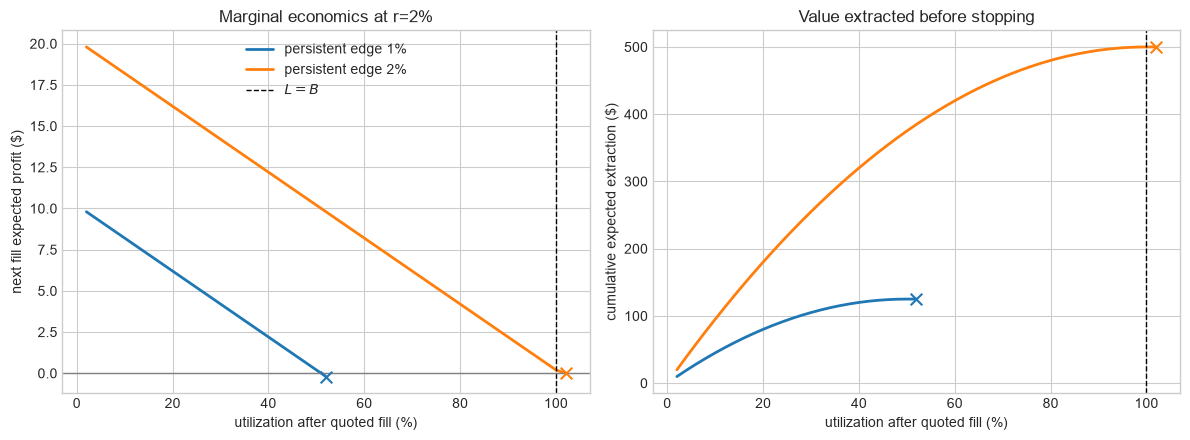

,edge,stop reason,final utilization,cumulative attacker profit ($)
6,1%,next fill is strictly unprofitable,50%,$125.00
24,2%,next fill reaches zero margin at the capped rate,100%,$500.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {10_000_000: "tab:blue", 20_000_000: "tab:orange"}
for edge_rate in EDGE_RATES:
    trace = attack_traces[(edge_rate, 20_000_000, 0.0)]
    label = f"persistent edge {edge_rate / FLOAT:.0%}"
    x = trace["utilization after quote"] * 100
    axes[0].plot(x, trace["incremental profit ($)"], color=colors[edge_rate], linewidth=2, label=label)
    axes[1].plot(x, trace["cumulative extraction ($)"], color=colors[edge_rate], linewidth=2, label=label)
    rejected = trace[~trace["accepted"]]
    if not rejected.empty:
        row = rejected.iloc[0]
        for ax, metric in zip(axes, ["incremental profit ($)", "cumulative extraction ($)"]):
            ax.scatter(row["utilization after quote"] * 100, row[metric], color=colors[edge_rate], marker="x", s=70, zorder=3)

for ax in axes:
    ax.axvline(100, color="black", linestyle="--", linewidth=1, label="$L=B$")
    ax.set_xlabel("utilization after quoted fill (%)")
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set(ylabel="next fill expected profit ($)", title="Marginal economics at r=2%")
axes[1].set(ylabel="cumulative expected extraction ($)", title="Value extracted before stopping")
axes[0].legend()
fig.tight_layout()
plt.show()

focus_results = attack_results[
    (attack_results["r"] == 0.02) & (attack_results["starting utilization"] == 0.0)
][["edge", "stop reason", "final utilization", "cumulative attacker profit ($)"]]
display(
    focus_results.style.format(
        {
            "edge": "{:.0%}",
            "final utilization": "{:.0%}",
            "cumulative attacker profit ($)": "${:,.2f}",
        }
    ).set_caption("Exact r=2% outcomes from an empty market")
)

In [5]:
# Part 3 — decide whether a rate is economically justified
reference_before = int(REFERENCE_UTILIZATION * B)
reference_quantity = REFERENCE_QUANTITY_DOLLARS * DUSDC
reference_delta_liability = int(REFERENCE_DELTA_L_PER_QUANTITY * reference_quantity)
reference_after = reference_before + reference_delta_liability

# Preserve the two-input decision frontier from the specification.
frontier_rows = []
for max_rate in CANDIDATE_RATES:
    rate = max_rate / FLOAT
    core = attack_results[
        (attack_results["edge"] == 0.02)
        & (attack_results["r"] == rate)
        & (attack_results["starting utilization"] == 0.0)
    ].iloc[0]
    attack_loss = core["cumulative attacker profit ($)"] if max_rate >= 20_000_000 else np.inf
    stopping_utilization = core["final utilization"] if max_rate >= 20_000_000 else np.inf
    reference_charge = dollars(inventory_impact(reference_before, reference_after, B, max_rate))
    frontier_rows.append(
        {
            "r": rate,
            "2c attack expected LP loss ($)": attack_loss,
            "2c stopping utilization": stopping_utilization,
            "reference charge ($)": reference_charge,
            "reference charge / quantity": reference_charge / REFERENCE_QUANTITY_DOLLARS,
        }
    )
frontier = pd.DataFrame(frontier_rows)

if MAX_ACCEPTABLE_LP_LOSS_DOLLARS is None or MAX_REFERENCE_CHARGE_DOLLARS is None:
    SELECTED_RATE = None
    print("No rate selected: set both team decision inputs to turn this frontier into a recommendation.")
else:
    frontier["LP loss constraint"] = frontier["2c attack expected LP loss ($)"] <= MAX_ACCEPTABLE_LP_LOSS_DOLLARS
    frontier["reference-cost constraint"] = frontier["reference charge ($)"] <= MAX_REFERENCE_CHARGE_DOLLARS
    passing = frontier[frontier["LP loss constraint"] & frontier["reference-cost constraint"]]
    SELECTED_RATE = None if passing.empty else float(passing.iloc[0]["r"])
    print(
        "No candidate satisfies both economic constraints."
        if SELECTED_RATE is None
        else f"Smallest candidate satisfying both constraints: r={SELECTED_RATE:.1%}."
    )

print(
    f"Reference trade: starts at {REFERENCE_UTILIZATION:.0%} utilization, "
    f"has ΔL/q={REFERENCE_DELTA_L_PER_QUANTITY:.3f}, and quantity=${REFERENCE_QUANTITY_DOLLARS:,.0f}."
)

# Headline settlement-held results requested for communication.
HEADLINE_EDGE_RATES = (20_000_000, 30_000_000, 40_000_000)
HEADLINE_MAX_RATES = (20_000_000, 25_000_000, 30_000_000, 40_000_000)
headline_rows = []
for edge_rate in HEADLINE_EDGE_RATES:
    for max_rate in HEADLINE_MAX_RATES:
        if max_rate < edge_rate:
            headline_rows.append(
                {
                    "theoretical edge": edge_rate / FLOAT,
                    "r": max_rate / FLOAT,
                    "utilization reached": np.inf,
                    "total traded ($)": np.inf,
                    "total pricing advantage ($)": np.inf,
                    "inventory skew savings ($)": np.inf,
                    "amount extracted ($)": np.inf,
                    "outcome": "no economic stop: edge exceeds capped rate",
                }
            )
            continue

        summary, _trace = run_attack(edge_rate, max_rate, 0.0)
        headline_rows.append(
            {
                "theoretical edge": edge_rate / FLOAT,
                "r": max_rate / FLOAT,
                "utilization reached": summary["final utilization"],
                "total traded ($)": summary["accepted quantity ($)"],
                "total pricing advantage ($)": summary["gross residual edge ($)"],
                "inventory skew savings ($)": summary["retained inventory impact ($)"],
                "amount extracted ($)": summary["cumulative attacker profit ($)"],
                "outcome": (
                    "zero margin at the cap"
                    if max_rate == edge_rate
                    else f"next fill rejected near {summary['final utilization']:.0%} utilization"
                ),
            }
        )

headline_results = pd.DataFrame(headline_rows)
headline_display = headline_results.copy()
headline_display["theoretical edge"] = headline_display["theoretical edge"].map(lambda value: f"{value:.0%}")
headline_display["r"] = headline_display["r"].map(lambda value: f"{value:.1%}")
headline_display["utilization reached"] = headline_display["utilization reached"].map(
    lambda value: "no stop" if np.isinf(value) else f"{value:.0%}"
)
for column in [
    "total traded ($)",
    "total pricing advantage ($)",
    "inventory skew savings ($)",
    "amount extracted ($)",
]:
    headline_display[column] = headline_display[column].map(
        lambda value: "unbounded" if np.isinf(value) else f"${value:,.2f}"
    )

display(
    headline_display.style.set_caption(
        "Settlement-held full pile-on from an empty market, B=$50,000 and $1,000 finite fills"
    )
)

No rate selected: set both team decision inputs to turn this frontier into a recommendation.
Reference trade: starts at 50% utilization, has ΔL/q=0.625, and quantity=$1,000.


,theoretical edge,r,utilization reached,total traded ($),total pricing advantage ($),inventory skew savings ($),amount extracted ($),outcome
0,2%,2.0%,100%,"$50,000.00","$1,000.00",$500.00,$500.00,zero margin at the cap
1,2%,2.5%,80%,"$40,000.00",$800.00,$400.00,$400.00,next fill rejected near 80% utilization
2,2%,3.0%,66%,"$33,000.00",$660.00,$326.70,$333.30,next fill rejected near 66% utilization
3,2%,4.0%,50%,"$25,000.00",$500.00,$250.00,$250.00,next fill rejected near 50% utilization
4,3%,2.0%,no stop,unbounded,unbounded,unbounded,unbounded,no economic stop: edge exceeds capped rate
5,3%,2.5%,no stop,unbounded,unbounded,unbounded,unbounded,no economic stop: edge exceeds capped rate
6,3%,3.0%,100%,"$50,000.00","$1,500.00",$750.00,$750.00,zero margin at the cap
7,3%,4.0%,74%,"$37,000.00","$1,110.00",$547.60,$562.40,next fill rejected near 74% utilization
8,4%,2.0%,no stop,unbounded,unbounded,unbounded,unbounded,no economic stop: edge exceeds capped rate
9,4%,2.5%,no stop,unbounded,unbounded,unbounded,unbounded,no economic stop: edge exceeds capped rate


### Interpretation

With the configured $50,000 scale and $1,000 fills, the central result is economic rather than relative to another fee:

- At `r=2%`, a persistent 1¢ edge can extract about **$125** from an empty same-range book before the next fill becomes unprofitable near 50% utilization.
- At `r=2%`, a persistent 2¢ edge can extract about **$500** before reaching the scale. Further fully capped fills have zero expected margin, but inventory impact never makes the edge strictly negative.
- A rate above 2% is required to strictly deter a 2¢ edge before the scale. For example, `r=2.5%` moves marginal break-even to roughly 80% utilization but still permits about **$400** of cumulative expected extraction from an empty book.

The final table extends the same calculation to persistent edges from 2¢ through 4¢. **Total pricing advantage** is the expected value available before inventory impact; **inventory skew savings** is the portion retained for LPs at settlement; and **amount extracted** is what remains with the attacker. For every bounded row, savings plus extraction equals the total pricing advantage.

The notebook intentionally does not select a rate while the acceptable LP-loss budget and reference-trade cost limit are unset. Those two inputs determine whether the economic protection is worth its cost.

Three limitations bound the conclusion:

1. A voluntary close can recover inventory escrow when liability returns to its starting state.
2. Disjoint adverse flow adds less liability and is therefore less affected than this full-pile-on attack.
3. Inventory impact is a backstop for adverse flow that creates persistent liability; it does not replace pricing correction or ordinary fees.